In [1]:
from importlib import reload
import torch
import numpy as np
import time
torch.set_default_dtype(torch.float64)
np.random.seed(2)
device = torch.device("cuda:3" if torch.cuda.is_available() else "cpu")
print(device)
import numpy as np
import sys #首先，添加路径，windows的路径和linux的路径符号不同\\,/,注意区别  #r是为了告诉python这是路径，别#把\n等特殊组合给转译）
sys.path.append(r"./main_code")
import generate_data2,grid_cell,adaptive_int_fix,visual,cal_S_grad,org_m,mea_2D,net_2D_fix2,S_valgrad,error_general_2D,main_fix,kidney_data,sign,smooth,true_bound,smooth
import matplotlib.pyplot as plt
CUDA_LAUNCH_BLOCKING=1

def kidney_curve(x, y, h, k, a):
    """
    计算给定点 (x, y) 的肾形线隐式函数值。
    
    参数:
    x, y: 输入的坐标点。
    h, k: 肾形线中心的坐标 (用于平移)。
    a:    肾形线的尺寸参数。
    """
    x_shifted = x - h
    y_shifted = y - k
    
    # 避免当 a=0 时出现问题
    if a == 0:
        a = 1e-9

    # 肾形线的隐式方程: (x_sh^2 + y_sh^2 - 4a^2)^3 - 108a^4 * y_sh^2 = 0
    term1 = (x_shifted**2 + y_shifted**2 - 4 * a**2)**3
    term2 = 108 * a**4 * y_shifted**2
    return term1 - term2

def Gauss_source(X,x_left,x_right,y_below,y_upper,center,r):
    # 1. 主高斯源 (模拟肿瘤)
    x=X[:,0]
    y=X[:,1]
    src1 = 1.2 * np.exp(-((x-0.3)**2 + (y-0.6)**2)/0.008)
    return src1

def kidney_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """肾形源项函数"""
    x = X[:, 0]
    y = X[:, 1]
    # 肾形源（平移+缩放）
    kidney_src = np.where(kidney_curve(x, y, h, k, s) <= 0, 1.0, 0.0)
    return kidney_src

def elegant_source(X,x_left,x_right,y_below,y_upper,center,r,h=0.6, k=0.25, s=0.05):
    """改进后的复杂源项函数"""
    gauss= Gauss_source(X,x_left,x_right,y_below,y_upper,center,r)
    # 肾形源（平移+缩放）
    kidney_src = kidney_source(X, x_left, x_right, y_below, y_upper, center, r, h, k, s)

    return kidney_src +gauss



cuda:3


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/_environment.py:541: UserWarning: 
--------------------------------------------------------------------------------

  CuPy may not function correctly because multiple CuPy packages are installed
  in your environment:

    cupy, cupy-cuda12x

  Follow these steps to resolve this issue:

    1. For all packages listed above, run the following command to remove all
       existing CuPy installations:

         $ pip uninstall <package_name>

      If you previously installed CuPy via conda, also run the following:

         $ conda uninstall cupy

    2. Install the appropriate CuPy package.
       Refer to the Installation Guide for detailed instructions.

         https://docs.cupy.dev/en/stable/install.html

--------------------------------------------------------------------------------

  warnings.warn(f'''


In [ ]:
import copy
np.random.seed(2)
torch.manual_seed(2)
torch.cuda.manual_seed_all(2) #固定随机种子
Nx,Ny=1,1
Ix,Iy=4,4  #x方向网格点
nx,ny=3,3  #每个网格x方向的高斯点
kk=[1,5,9,13,17,21,25,29,33,37,41,45,49,53,57,61,65,69,73,77,81,85,89,93,97,101] #网格点索引
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
b_x_min,b_x_max,b_y_min,b_y_max=-0.5,1.5,-0.5,1.5 #边界gamma处

num_batches_gauss=1
b_n=20
points_b=mea_2D.p_b(b_x_min,b_x_max,b_y_min,b_y_max,b_n) #在边界Γ处收集数据
x_left,x_right,y_below,y_upper=0.29,0.49,0.3,0.7
r_true=0.2
center_true=np.array([0.6,0.25])
number_gene=50
eps=0.05
batch_number_rec_mea,mea=2,1
cupy_device=3
number=120
a=0.05
S_int_true,F_mea_b,F_mea_db_x1,F_mea_db_x2=kidney_data.boundary_data_circle(kk,120,points_b,kidney_source,0,1,0,1,center_true,1,a,eps,mea,batch_number_rec_mea,device,cupy_device)
S_int_true_g,F_mea_b_g,F_mea_db_x1_g,F_mea_db_x2_g=kidney_data.boundary_data_rec(kk,120,points_b,Gauss_source,0,1,0,1,center_true,1,eps,mea,batch_number_rec_mea,device,cupy_device)
F=org_m.F(F_mea_b+F_mea_b_g,F_mea_db_x1+F_mea_db_x1_g,F_mea_db_x2+F_mea_db_x2_g)
cells= grid_cell.create_initial_grid(tau_x_min,tau_x_max,tau_y_min,tau_y_max,Ix,nx,points_b) #创造初始网格
initial_cells=copy.deepcopy(cells) #copy一份
R_m=20


In [4]:
M=1600
af="Tanh"   #先用tanh
R_m=20
cupy_device= 3
model_tanh = net_2D_fix2.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=0.18, r_max=0.22,b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=[],K_max=[],R_m_for_init=R_m,af="Tanh",Shape="general",device=device).to(device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


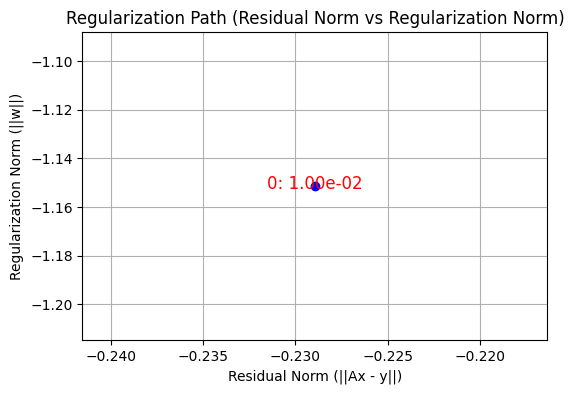

第 0 次迭代的train误差：
S_l_inf= 2.6932729697817095 S_L_2= 0.2740370981360954 S_l_2= 0.8150143287258766
第 0 次迭代的泛化误差：


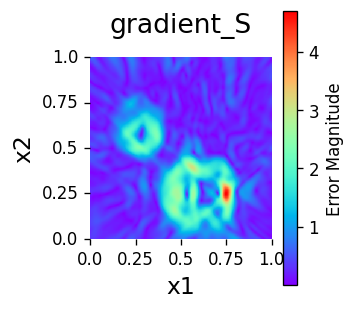

S_l_inf= 3.044484119262387 S_L_2= 0.27918102105978077 S_l_2= 0.8355598076775562


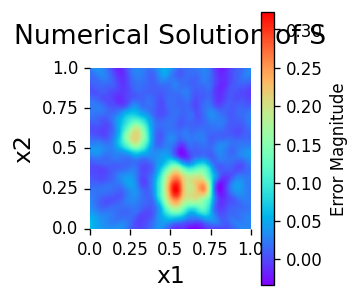

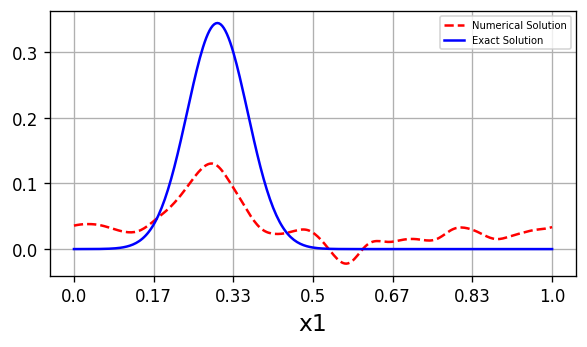

第 0 次自适应网格细分...
S_l_inf= 2.6932729697817095 S_L_2= 0.2740370981360954 S_l_2= 0.8150143287258766
S_l_inf= 2.9628757196112527 S_L_2= 0.2848238775181931 S_l_2= 0.8396658873977787
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


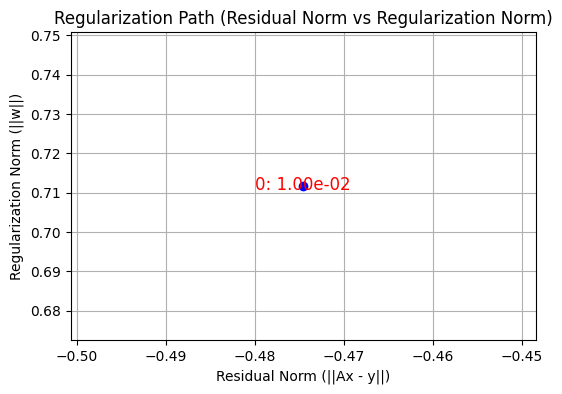

第 1 次迭代的train误差：
S_l_inf= 3.536260458067849 S_L_2= 0.17785709434647415 S_l_2= 0.5243258966056438
第 1 次迭代的泛化误差：


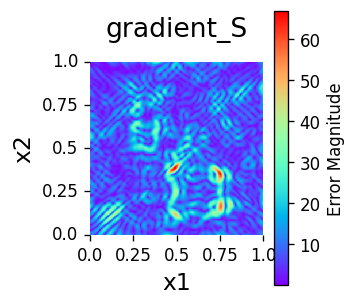

S_l_inf= 4.199598944285419 S_L_2= 0.19927162187697062 S_l_2= 0.5963992731993879


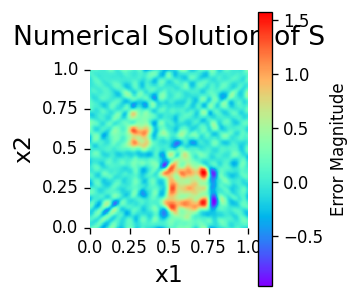

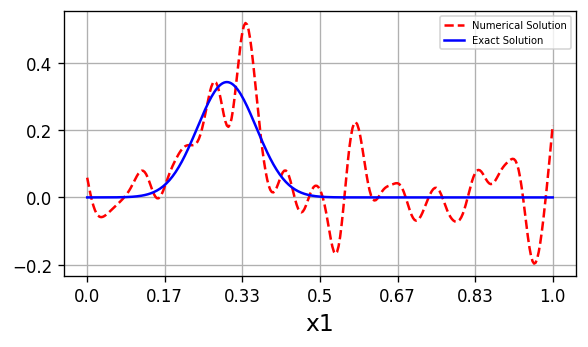

第 1 次自适应网格细分...
S_l_inf= 3.536260458067849 S_L_2= 0.17785709434647415 S_l_2= 0.5243258966056438
S_l_inf= 3.370150652998813 S_L_2= 0.18940666483678273 S_l_2= 0.5663510689103604
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


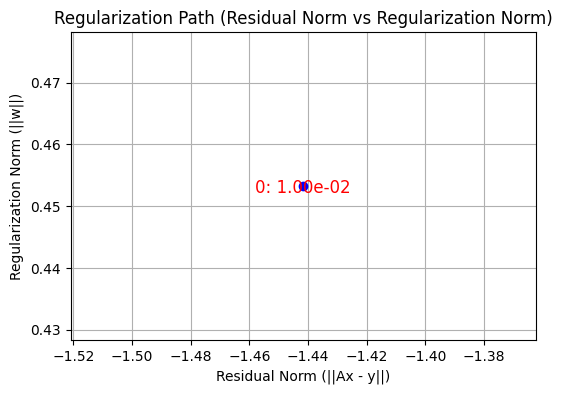

第 2 次迭代的train误差：
S_l_inf= 1.477800711767984 S_L_2= 0.06687495775820539 S_l_2= 0.19401847583020346
第 2 次迭代的泛化误差：


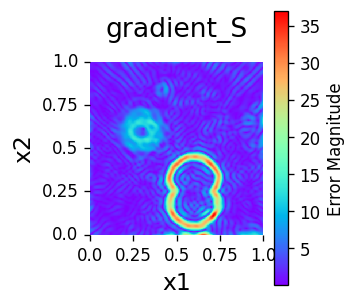

S_l_inf= 2.649360598328138 S_L_2= 0.0675084000960335 S_l_2= 0.20204563185110933


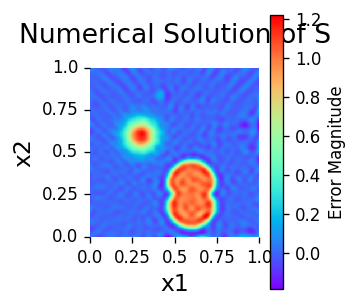

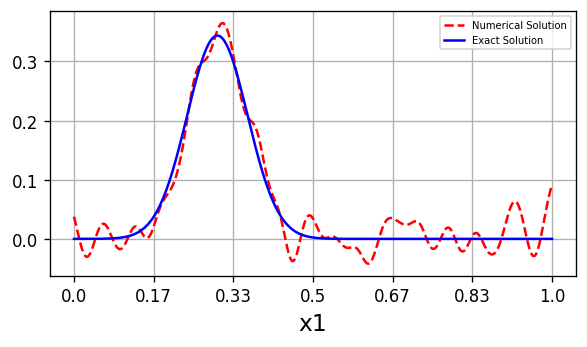

第 2 次自适应网格细分...
S_l_inf= 1.477800711767984 S_L_2= 0.06687495775820539 S_l_2= 0.19401847583020346
S_l_inf= 1.60933072747552 S_L_2= 0.0674129125837756 S_l_2= 0.19501227117850317
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


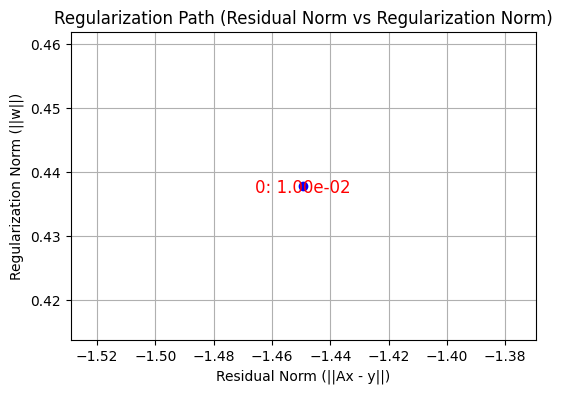

第 3 次迭代的train误差：
S_l_inf= 1.0384593203058115 S_L_2= 0.09845718479099307 S_l_2= 0.18560710851022488
第 3 次迭代的泛化误差：


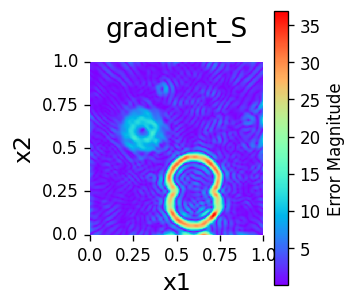

S_l_inf= 2.5729687876702894 S_L_2= 0.06655603281777643 S_l_2= 0.19919529547495402


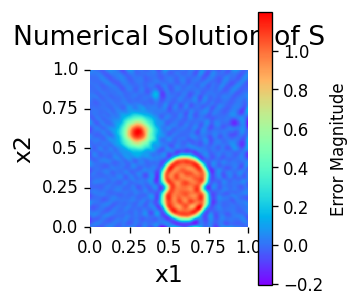

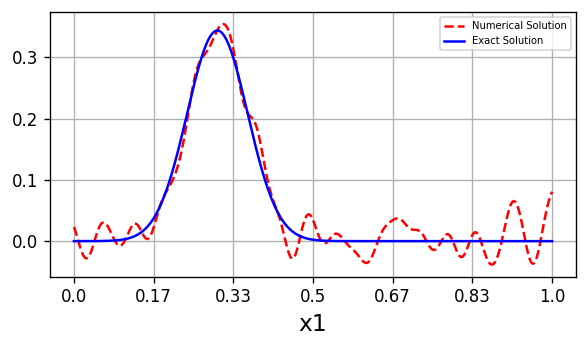

第 3 次自适应网格细分...
S_l_inf= 1.0384593203058115 S_L_2= 0.09845718479099307 S_l_2= 0.18560710851022488
S_l_inf= 1.2864945643581644 S_L_2= 0.09994217981203556 S_l_2= 0.1886795386073303
Generating visualizations...
1. Plotting mesh comparison with solution overlay...


<Figure size 640x480 with 0 Axes>

All visualizations completed!


/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


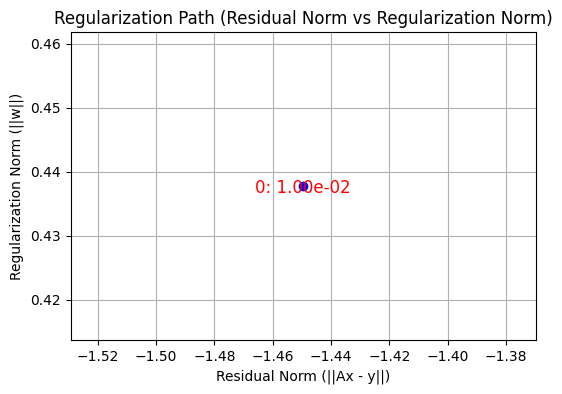

第 4 次迭代的train误差：
S_l_inf= 1.04525937343173 S_L_2= 0.14797083960475674 S_l_2= 0.22695756163324768
第 4 次迭代的泛化误差：


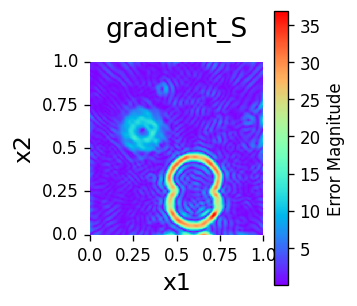

S_l_inf= 2.5729636439676717 S_L_2= 0.06655671234286267 S_l_2= 0.19919732922297964


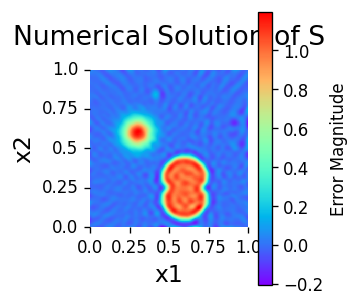

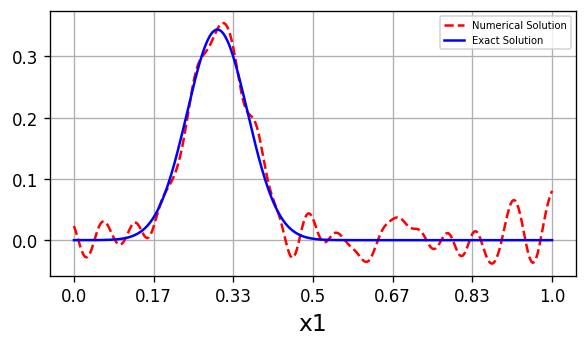

在第 4 次迭代结束


In [5]:
iter_int= 5
Ix,Iy=4,4  #x方向网格点
delta=10**(-3)
nx=3
lamb_regu=np.logspace(-2,-1,1)
Qx,Qy=150,150
max_level=4
current_maxiter=1
af="Tanh"
Shape=[]
refine_threshold_S=[5e-5, 1e-4, 5e-4, 1e-3, 5e-3] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-7, 1e-7, 8e-7, 8e-7, 8e-7] #刚开始阈值小多细分，后面阈值大少细分
#refine_threshold_grad=[1e-8, 1e-8, 1e-7, 1e-7, 1e-6] #刚开始阈值小多细分，后面阈值大少细分
refine_threshold_grad=[5e-9, 1e-8, 5e-8, 1e-7, 5e-7]
refine_threshold_noise=[1e-2,1e-2,1e-2,1e-2,1e-2,1e-2]
# using main_fix.ada_int_fix
cells_store,refinement_stats_store,w_,point_number,g_store,g_S,S_l2,S_num_store=main_fix.ada_int(iter_int,delta,cells,nx,model_tanh,M,af,Shape,[],kk,F,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,elegant_source,points_b,lamb_regu,Qx,Qy,device,cupy_device,refine_threshold_S,refine_threshold_grad,refine_threshold_noise,current_maxiter,max_level)

In [6]:
len(cells_store[-1])

703

In [ ]:
np.save("./noise=5%/S_num_store_ada.npy",S_num_store)

In [ ]:
np.save("./noise=5%/g_S.npy",g_S)

In [ ]:
g_S=np.load("./noise=5%/g_S.npy",allow_pickle=True)
S_num_store=np.load("./noise=5%/S_num_store_ada.npy",allow_pickle=True)

In [25]:
g_S.shape

(301, 301)

Number of detected clusters: 2
CurvStd=0.630, PeakRatio=3.67 -> general
Cluster 0: AR=1.23
  Res_Rect=0.311 vs Res_Ellip=0.385
  -> Winner: general
  CV of S_num: 0.126
Cluster 0: Lx=0.136, Ly=0.110, AR=1.23
  -> Decision: general (Sigmoid)
CurvStd=0.412, PeakRatio=7.40 -> general
Cluster 1: AR=1.32
  Res_Rect=0.071 vs Res_Ellip=0.074
  -> Winner: general
  CV of S_num: 0.639
Cluster 1: Lx=0.320, Ly=0.423, AR=1.32
  -> Decision: general (Sigmoid)


/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/2d_inverse_source_Kernet_DirNeu_kidney/./main_code2/bound_detect.py:430: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.


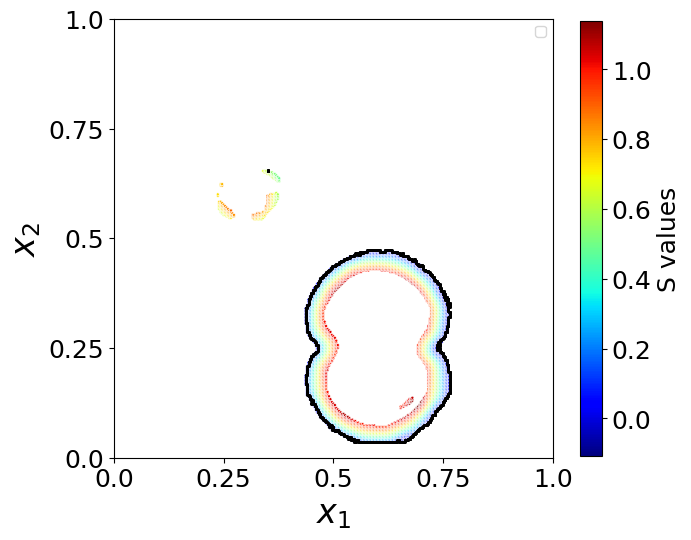

<Figure size 640x480 with 0 Axes>

In [ ]:
from importlib import reload
import bound_detect
reload(bound_detect)
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.05
mini_samples=10
para_abs=100
para_grad=3
results=bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./noise=5%", output_filename="plot.png")

In [41]:
results

[{'cluster_id': 0,
  'shape': 'general',
  'params': {'center': array([0.32024963, 0.5818649 ]),
   'W': np.float64(0.13580000000000006),
   'H': np.float64(0.10999999999999999)},
  'profile': 'Sigmoid'},
 {'cluster_id': 1,
  'shape': 'general',
  'params': {'center': array([0.59992272, 0.2498921 ]),
   'W': np.float64(0.32),
   'H': np.float64(0.4233333333333334)},
  'profile': 'Exp'}]

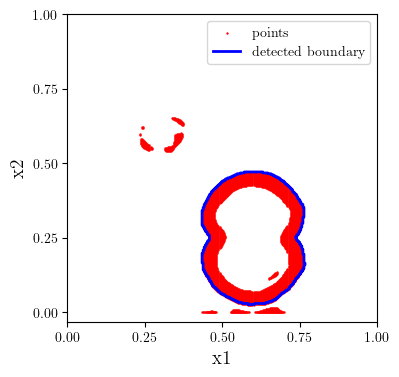

In [ ]:
import bound_detect
kidney_bound=bound_detect.detect(kidney)

In [11]:
kidney_bound.shape

(1795, 2)

In [ ]:
np.save("./noise=5%/kidney_num.npy",kidney_bound)

In [13]:
# 2. 设置参数并从隐式函数中提取边界点
func_params = {'h': 0.6, 'k': 0.25, 'a': a}
contour_points_implicit = true_bound.get_contour_points_from_implicit(
    kidney_curve,
    func_args=func_params,
    x_range=(0, 1),
    y_range=(0, 1)
)


/data5/store1/hxw/inverse_source/Kernet/2d_inverse_source_Kernet_DiriNeu_objects/2d_inverse_source_Kernet_DirNeu_kidney/./main_code2/true_bound.py:51: RuntimeWarning: overflow encountered in exp
  z_flat = 1 / (1 + np.exp(K * signed_distances))


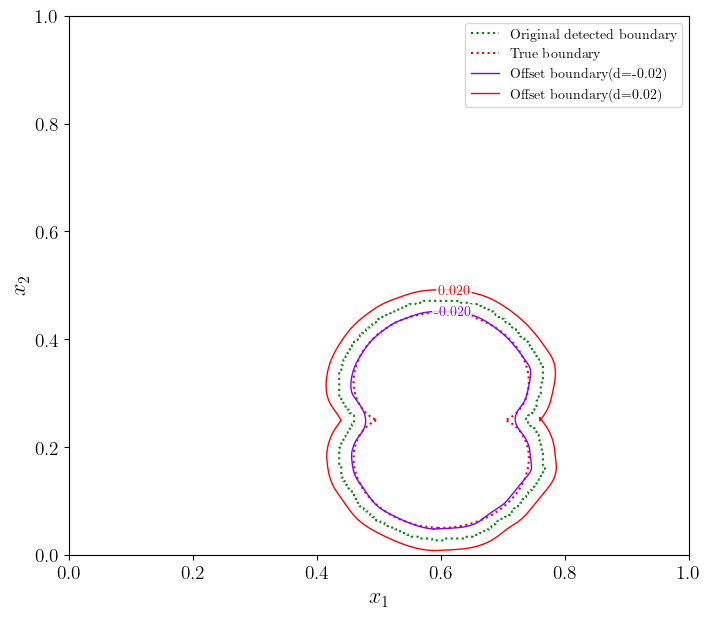

In [ ]:
import numpy as np
from scipy.interpolate import splprep, splev
#splprep 创造参数化样条曲线

# 4. 对【平滑后】的边界进行偏移
offset_distances = np.linspace(-0.02,0.02
                               ,2)


kidney_boundary=kidney_bound
alpha=2*10**(-3)
contour_points_scaled = smooth.simple_offset_batch(kidney_boundary, alpha,offset_distances)

# 5. 生成用于可视化的二维网格点
x = np.linspace(0, 1, 150)
y = np.linspace(0, 1, 150)
X, Y = np.meshgrid(x, y)

# 6. 使用【最终偏移后】的边界点计算软边界函数值
Z = true_bound.generate_soft_boundary(X, Y, contour_points_implicit, K=2000)

# 8. 绘制二维轮廓图以进行清晰对比
plt.figure(figsize=(8, 7))

# 绘制对比边界
plt.plot(kidney_boundary[:, 0], kidney_boundary[:, 1], c='g', linestyle=':', label='Original detected boundary')
plt.plot(contour_points_implicit[:, 0], contour_points_implicit[:, 1], c='r', linestyle=':', label='True boundary')
colors = plt.cm.rainbow(np.linspace(0, 1, len(offset_distances)))
for i, d in enumerate(offset_distances):
    plt.plot(contour_points_scaled[i,:, 0], contour_points_scaled[i,:, 1], color=colors[i], linewidth=1, label=f'Offset boundary(d={d})')
    if abs(d) > 1e-6:
        # 为了避免标签重叠，可以选择不同的位置
        # 例如，对于正偏移，我们取曲线的1/4处；对于负偏移，取3/4处
        if d > 0:
            label_position_index = len(contour_points_scaled[1]) // 2
        else:
            label_position_index = ( len(contour_points_scaled[1])) // 2
            
        point_for_label = contour_points_scaled[i,label_position_index,:]
        
        plt.text(
            x=point_for_label[0],
            y=point_for_label[1],
            s=f'{d:.3f}',
            color=colors[i],
            fontweight='bold',
            fontsize=10,
            ha='center',
            va='center',
            bbox=dict(facecolor='white', alpha=0.8, edgecolor='none', pad=1.5)
        )
#plt.title('Boundary Smoothing and Offsetting Comparison')
plt.xlabel('$x_1$',fontsize=16)
plt.ylabel('$x_2$',fontsize=16)
plt.xticks(fontsize=14)
plt.yticks(fontsize=14)
plt.xlim(0, 1)
plt.ylim(0, 1)
plt.legend()
plt.savefig("./noise=5%/缩放.png", dpi=300, bbox_inches='tight')
plt.show()


In [16]:
import sign
M_sig=1600
kidney_boundary = kidney_bound #读取肾性数值边界 不准！
alpha = 2* 10**(-3)  # 平滑参数
scale_factor  = np.random.uniform(low=-0.03, high=-0.01, size=M_sig)
#scale_factor =np.linspace(-0.03,-0.01,M_sig)
scale_curves,sign_distances_t=sign.generate_signed_distance(g_store[-1], kidney_bound, alpha,scale_factor,M_sig)

In [17]:
scale_factor_noise =np.linspace(-0.02,-0.01,1)
sign_distance_t=sign
bound_num_scaled=smooth.simple_offset_batch(kidney_boundary,alpha, scale_factor_noise) #平滑边界
b1_noise=(bound_num_scaled.reshape(-1,2))[:,0]
b2_noise=(bound_num_scaled.reshape(-1,2))[:,1]

In [18]:
K_min=1000
K_max=30000
modelsig = net_2D_fix2.local_rep(in_features=2, out_features=1, hidden_layers=1, M=M_sig, M_noise=[],b1_noise=[],b2_noise=[],x_max=1, x_min=0, y_max=1, y_min=0, r_min=0.18, r_max=0.22,b1_min=[],b1_max=[],b2_min=[],b2_max=[],width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="sigmoid",Shape="general",device=device).to(device)
modelnoise = net_2D_fix2.local_rep(in_features=2, out_features=1, hidden_layers=1, M=1, M_noise=b1_noise.shape[0],b1_noise=-b1_noise,b2_noise=-b2_noise,x_max=1, x_min=0, y_max=1, y_min=0, r_min=0, r_max=0.05,b1_min=0,b1_max=1,b2_min=0,b2_max=1,width_min=[],width_max=[],height_min=[],height_max=[],peak_min=[],peak_max=[],v_min=[],v_max=[],K_min=K_min,K_max=K_max,R_m_for_init=R_m,af="sigmoid",Shape="noise",device=device).to(device)

In [19]:
sum_mat,all_g_p1,all_g_n,cells_copy1=cal_S_grad.mat_assemble2(cells_store[-1],model_tanh,modelsig,modelnoise,[],"mix","general","noise",sign_distances_t,kk,0,points_b,device,cupy_device)

/data5/store1/hxw/anaconda3/envs/inverse1/lib/python3.9/site-packages/cupy/linalg/_solve.py:171: FutureWarning: `rcond` parameter will change to the default of machine precision times ``max(M, N)`` where M and N are the input matrix dimensions.
To use the future default and silence this warning we advise to pass `rcond=None`, to keep using the old, explicitly pass `rcond=-1`.
  warnings.warn(


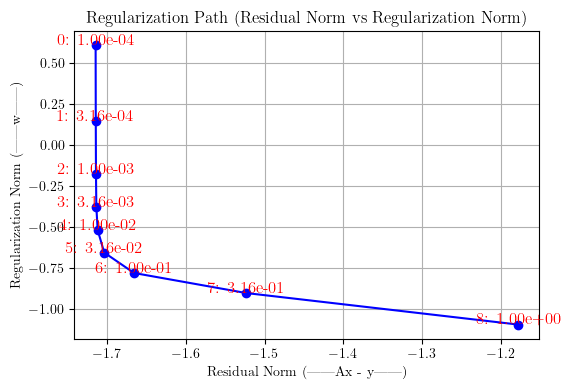

In [20]:
lamb_regu=np.logspace(-4,0,9,endpoint=True)
res,reg_norm,w_store=org_m.L_curve(sum_mat,F,[],[],[],lamb_regu,"linear",device,cupy_device) #先进行求解q

In [21]:
sample_s=error_general_2D.test_p(Qx,Qy,tau_x_min,tau_x_max,tau_y_min,tau_y_max)
whatever,sign_distances_test=sign.generate_signed_distance(sample_s, kidney_bound, alpha, scale_factor, M_sig)

0.0009999999999999998
S_l_inf= 2.805401818766697 S_L_2= 0.039196516251688386 S_l_2= 0.11731110322817398


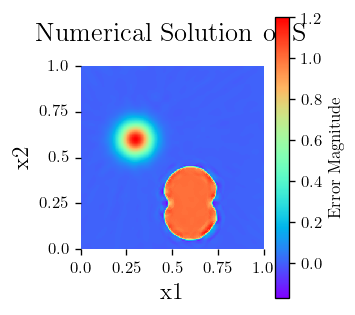

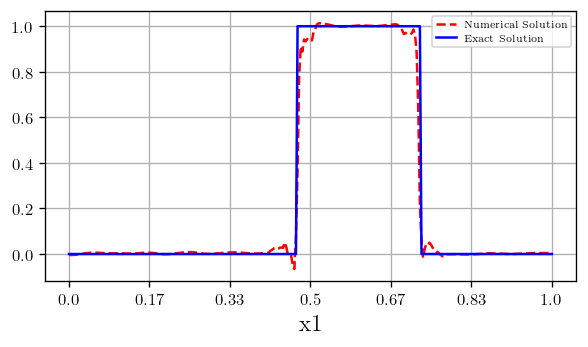

In [31]:
length=sample_s.shape[0] #测试点个数
print(lamb_regu[5]**2)
S_test_num,S_test_true,S_l_inf1,S_l_21,g_SS=error_general_2D.test(model_tanh,modelsig,modelnoise,[],sample_s,w_store[:,5
                                                                                                                  ],"mix","general","noise",sign_distances_test,True,True,tau_x_min,tau_x_max,tau_y_min,tau_y_max,x_left,x_right,y_below,y_upper,center_true,r_true,elegant_source,0.27,0,device)

In [ ]:
import pickle

with open("./noise=5%/cells_store_last.pkl", "wb") as f:
    pickle.dump(cells_store[-1], f)

In [ ]:
np.save("./noise=5%/sign_distances_test.npy", sign_distances_test)
np.save("./noise=5%/sign_distances_train.npy", sign_distances_t)

In [ ]:
np.save("./noise=5%/sign_distances_test.npy",sign_distances_test)
np.save("./noise=5%/w_store.npy", w_store)

In [ ]:
np.save("./noise=5%/S_test_num.npy",S_test_num)
np.save("./noise=5%/S_test_true.npy",S_test_true)
np.save("./noise=5%/g_SS.npy",g_SS)

In [ ]:
torch.save(model_tanh.state_dict(), "./noise=5%/model_tanh.pth")
torch.save(modelsig.state_dict(), "./noise=5%/model_sig.pth")
torch.save(modelnoise.state_dict(), "./noise=5%/model_noise.pth")

In [ ]:
g_S=np.load("./noise=5%/g_S.npy",allow_pickle=True)
S_num_store=np.load("./noise=5%/S_num_store_ada.npy",allow_pickle=True)

Number of detected clusters: 2
CurvStd=0.630, PeakRatio=3.67 -> general
Cluster 0: AR=1.23
  Res_Rect=0.311 vs Res_Ellip=0.385
  -> Winner: general
  CV of S_num: 0.126
Cluster 0: Lx=0.136, Ly=0.110, AR=1.23
  -> Decision: general (Sigmoid)
  Center: (0.320, 0.582)
    Rect Residual: 0.3109, Ellip Residual: 0.3855
    Aspect Ratio: 1.235
    Curvature - Std: 0.6298, Mean: 0.3857, Peak Ratio: 3.67
CurvStd=0.412, PeakRatio=7.40 -> general
Cluster 1: AR=1.32
  Res_Rect=0.071 vs Res_Ellip=0.074
  -> Winner: general
  CV of S_num: 0.639
Cluster 1: Lx=0.320, Ly=0.423, AR=1.32
  -> Decision: general (Sigmoid)
  Center: (0.600, 0.250)
    Rect Residual: 0.0708, Ellip Residual: 0.0743
    Aspect Ratio: 1.323
    Curvature - Std: 0.4121, Mean: 0.1911, Peak Ratio: 7.40


/data5/store1/hxw/inverse_source/AMain/Bound_detect.py:431: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax = plt.gca()


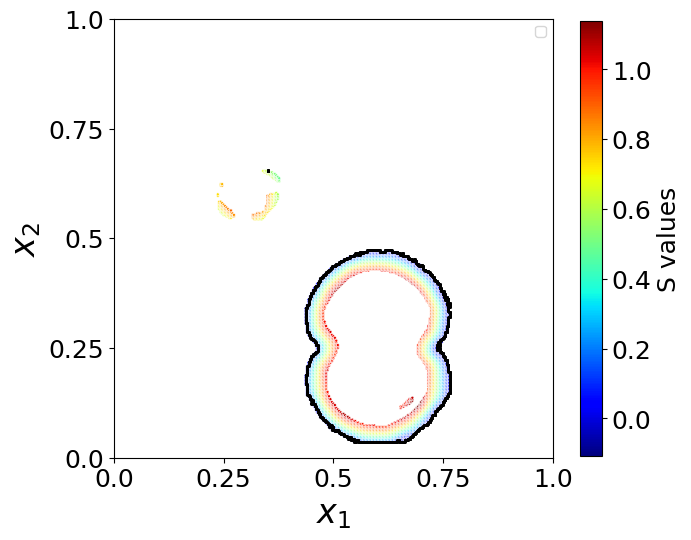

<Figure size 640x480 with 0 Axes>

In [ ]:
import Bound_detect
reload(Bound_detect)
tau_x_min,tau_x_max,tau_y_min,tau_y_max=0,1,0,1
x=np.linspace(tau_x_min,tau_x_max,301)
y=np.linspace(tau_y_min,tau_y_max,301)
X,Y=np.meshgrid(x,y)
eps_cluster=0.05
mini_samples=10
para_abs=100
para_grad=3
results=Bound_detect.detect_shape(g_S,X.T,Y.T,tau_x_min,tau_x_max,tau_y_min,tau_y_max,para_abs,para_grad,eps_cluster,mini_samples,S_num_store[-1],output_directory="./noise=5%", output_filename="plot.png")